<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/56SVMClassifierPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%load_ext cuml.accel

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
import matplotlib.pyplot as plt

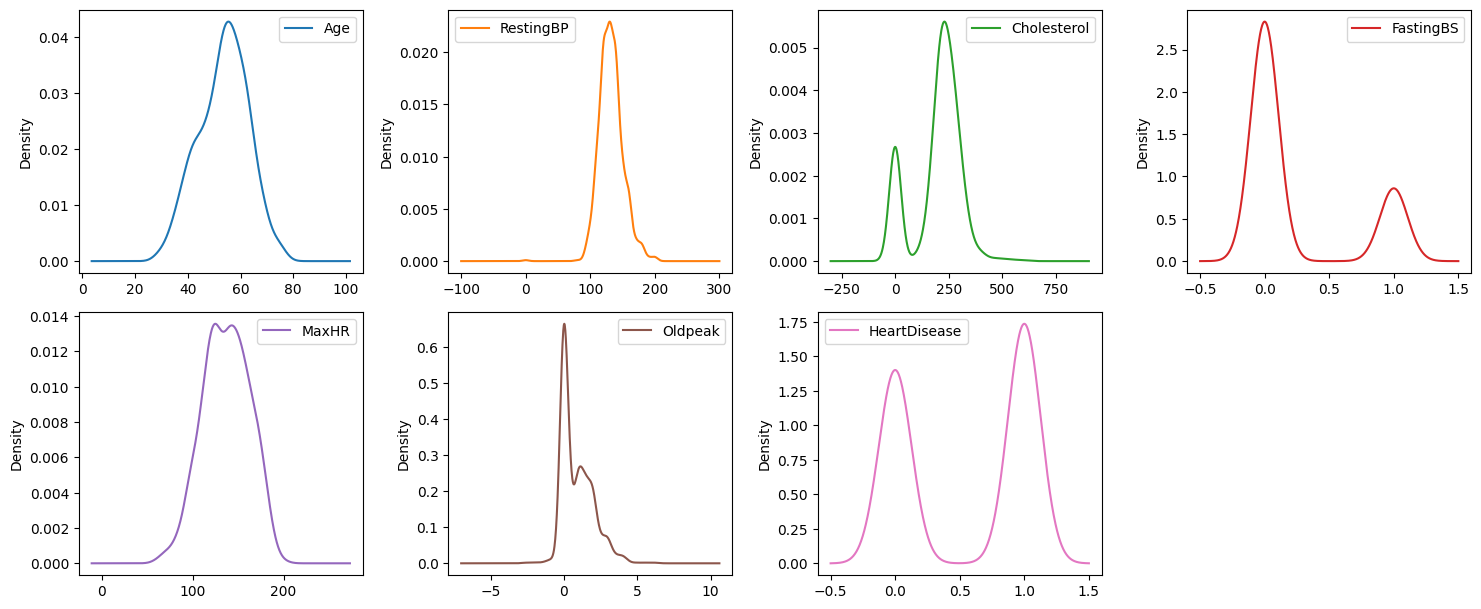

In [8]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.plot(
    kind='kde',
    subplots=True,
    layout=(4, 4),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.tight_layout()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X = df.drop(['HeartDisease'],axis=1)
y = df['HeartDisease']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
numerical_cols_for_outliers_split = ['Cholesterol', 'RestingBP']

for col in numerical_cols_for_outliers_split:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [13]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

In [14]:
one_hot_encoder = Pipeline(
    steps=[
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

In [15]:
categories = [['Up', 'Flat', 'Down']]

In [16]:
ordinal_encoder = Pipeline(
    steps=[
        ('encoder',OrdinalEncoder(categories=categories))
    ]
)

In [17]:
standard_scaling = Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',one_hot_encoder,['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']),
        ('pipeline_2',ordinal_encoder,['ST_Slope']),
        ('pipeline_3',standard_scaling,['Age','RestingBP','Cholesterol','MaxHR', 'Oldpeak'])
    ],
    remainder='passthrough'
)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('pipeline_1',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'ChestPainType', 'RestingECG',
                                  'ExerciseAngina']),
                                ('pipeline_2',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['Up',
                                                                              'Flat',
                                                                              'Down']]))]),
                                 ['ST_Slope']),
                                ('pipeline_3',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'RestingBP', 'Cholesterol', 'MaxHR',
                                  'Oldpeak'])])

In [19]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

In [20]:
from sklearn.svm import SVC

In [21]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [22]:
for kernel in kernels:
  model = Pipeline(
      steps=[
          ('preprocessor', preprocessor),
          ('classifier', SVC(kernel=kernel, random_state=42))
      ]
  )
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)

    # Save metrics
  results.append({
        'Kernel': kernel.capitalize(),
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}"
    })

In [23]:
result_df = pd.DataFrame(results)
print(result_df)

    Kernel Accuracy Precision  Recall
0   Linear   0.8696    0.8482  0.9314
1     Poly   0.8696    0.8900  0.8725
2      Rbf   0.8804    0.8636  0.9314
3  Sigmoid   0.8152    0.7881  0.9118


In [24]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
X = df.drop(['Churn'],axis=1)
y = df['Churn']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
X_train.drop(columns = ['customerID'], inplace=True)
X_test.drop(columns = ['customerID'], inplace=True)

In [28]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [29]:
numerical_transfomer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categroical_transfomer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(sparse_output=False,drop='first', handle_unknown='ignore'))
    ]
)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categroical_transfomer, categorical_cols),
        ('num', numerical_transfomer, numerical_cols)
    ],
    remainder = 'drop'
)
preprocessor

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'TotalCharges']),
                                ('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure',
                                  'MonthlyCharges'])])

In [31]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [32]:
y_train

array([0, 0, 0, ..., 1, 0, 0])

In [33]:
SVC_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',SVC())
    ]
)

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
grid_params = {
    'model__C':[0.1,1,10],
    'model__kernel':['linear', 'rbf', 'poly', 'sigmoid'],
    'model__gamma':['scale', 'auto']
}

In [36]:
best_SVC_model = GridSearchCV(estimator = SVC_model , param_grid = grid_params , cv = 5)

In [37]:
best_SVC_model.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod',
                                                                          'TotalCharges']),
                                                                        ('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges'])])),
                                       ('model', SVC())]),
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf', 'poly', 'sigmoid']})

In [38]:
best_SVC_model.best_params_

{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

In [40]:
best_model = best_SVC_model.best_estimator_

In [41]:
y_pred = best_model.predict(X_test)

In [43]:
from sklearn.metrics import classification_report

In [44]:
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

